# Exploring the CBIS-DDSM Dataset

## ¿Qué vamos a descubrir?

En este notebook exploraremos la **metadata** del conjunto CBIS-DDSM antes de mirar imágenes. La idea es seguir el recorrido de una anotación:

1. **Conocer los datos:** qué representa cada fila y qué columnas tenemos.
2. **Encontrar patrones:** distribución de casos, vistas, evaluaciones y diagnósticos.
3. **Seguir un caso:** conectar la información de una paciente con sus anotaciones.
4. **Pasar a la imagen:** localizar una mamografía, su ROI y su máscara cuando los archivos DICOM estén disponibles.

> Nota: este notebook usa los CSV incluidos en `data/`. Las imágenes DICOM no están incluidas en este repositorio; la última sección se activa al indicar su carpeta.

## 1. Preparar el entorno y cargar la metadata

### Importar librerías

Usaremos `pandas` para las tablas, `matplotlib` para las gráficas y `pydicom` para leer imágenes médicas cuando estén disponibles.

In [1]:
import pandas as pd                    # Data manipulation and analysis
import numpy as np                     # Numerical operations
import os                              # File and folder navigation
import pydicom                         # Reading DICOM medical images
import matplotlib.pyplot as plt        # Image visualization

### ¿Qué significa una fila?

Cada fila describe una **anotación** de una lesión, no necesariamente una paciente distinta. Por eso una misma `patient_id` puede aparecer varias veces.

Las columnas más importantes para esta exploración son:

| Columna | Pregunta que ayuda a responder |
| --- | --- |
| `patient_id` | ¿A qué caso pertenece la anotación? |
| `left or right breast` | ¿En qué mama está la lesión? |
| `image view` | ¿Se observa en la vista `CC` o `MLO`? |
| `abnormality id` | ¿Cuál de las lesiones del caso es? |
| `calc type` y `calc distribution` | ¿Qué aspecto y distribución tienen las calcificaciones? |
| `assessment` | ¿Qué categoría BI-RADS se registró? |
| `pathology` | ¿Cuál es el diagnóstico de referencia? |
| `image file path`, `cropped image file path`, `ROI mask file path` | ¿Dónde están la imagen completa, el recorte y la máscara? |

Los campos de masas pueden aparecer vacíos porque este archivo describe calcificaciones. Primero confirmaremos qué hay realmente en el CSV, en lugar de asumirlo.

> Una buena exploración empieza comprobando los nombres de las columnas y los valores ausentes. Así evitamos interpretar como un dato real algo que en este archivo no aplica.

### Cargar el CSV de calcificaciones

Comenzamos con el conjunto de entrenamiento de calcificaciones. La ruta se construye de forma relativa al proyecto para que el notebook sea reproducible en otros equipos.

In [2]:
from pathlib import Path

# Buscamos la carpeta data tanto si el notebook se ejecuta desde el proyecto
# como si se ejecuta desde la carpeta notebooks.
DATA_DIR = next(
    (candidate for candidate in (Path("data"), Path("../data")) if candidate.exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta data/. Ejecuta el notebook desde el proyecto.")

CALC_CSV = DATA_DIR / "calc_case_description_train_set.csv"
df = pd.read_csv(CALC_CSV)

print(f"Archivo: {CALC_CSV.resolve()}")
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")

Archivo: C:\Proyectos\PROYECTO-LY\mamografia-a-la-deteccion\data\calc_case_description_train_set.csv
Filas: 1,546 | Columnas: 14


In [3]:
# Las primeras filas permiten comprobar la forma de los datos y reconocer sus columnas.
df.head(3)

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...


## 2. Hacer preguntas sencillas a la tabla

Antes de seleccionar una paciente, revisemos el tamaño del conjunto, los casos únicos y los valores ausentes. Estas comprobaciones nos dicen qué tan completa es la metadata.

In [4]:
# Resumen de calidad: una fila es una anotación y un paciente puede tener varias filas.
resumen = pd.Series({
    "filas (anotaciones)": len(df),
    "pacientes únicos": df["patient_id"].nunique(),
    "columnas": df.shape[1],
    "campos con algún valor ausente": int(df.isna().any().sum()),
})
resumen.to_frame("valor")

,valor
filas (anotaciones),1546
pacientes únicos,602
columnas,14
campos con algún valor ausente,2


### ¿Qué valores aparecen con más frecuencia?

Estas frecuencias nos ayudan a distinguir variables clínicas de variables de identificación. Empezamos por las categorías que sí podemos comparar directamente.

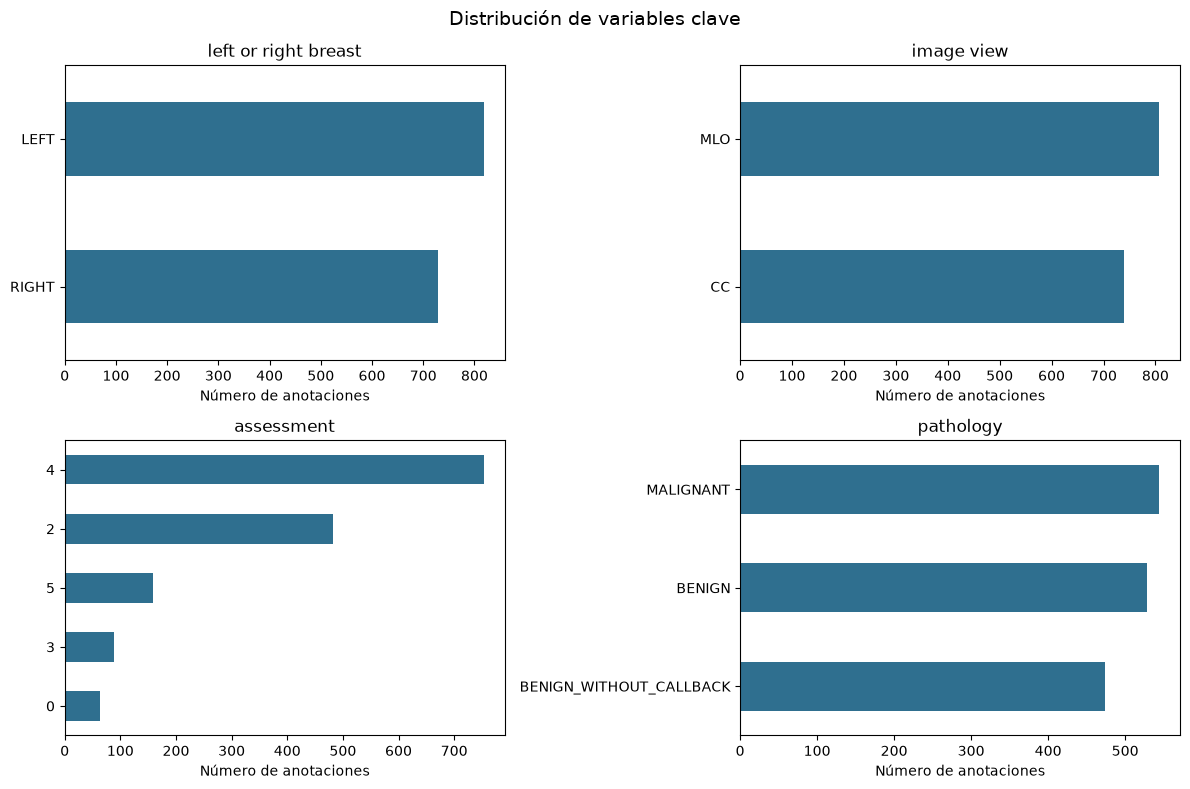

In [5]:
columnas_interes = [
    "left or right breast",
    "image view",
    "assessment",
    "pathology",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, column in zip(axes.flat, columnas_interes):
    conteos = df[column].fillna("Sin dato").value_counts()
    conteos.sort_values().plot.barh(ax=axis, color="#2f6f8f")
    axis.set_title(column)
    axis.set_xlabel("Número de anotaciones")
    axis.set_ylabel("")

fig.suptitle("Distribución de variables clave", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Seguir un caso de principio a fin

Elegimos automáticamente el primer caso disponible para que el ejemplo funcione aunque cambie el contenido del CSV. Después podremos cambiar `patient_id` por cualquier valor que queramos investigar.

In [12]:
# Usamos P_00030 porque es el caso didáctico copiado en data/CBIS-DDSM/.
patient_id = "P_00030"
columnas_caso = [
    "patient_id",
    "left or right breast",
    "image view",
    "abnormality id",
    "calc type",
    "calc distribution",
    "assessment",
    "pathology",
    "subtlety",
]

caso = df.loc[df["patient_id"] == patient_id, columnas_caso]
print(f"Caso seleccionado: {patient_id} | Anotaciones: {len(caso)}")
caso

Caso seleccionado: P_00030 | Anotaciones: 6


,patient_id,left or right breast,image view,abnormality id,calc type,calc distribution,assessment,pathology,subtlety
42,P_00030,LEFT,CC,1,COARSE,NaN,2,BENIGN_WITHOUT_CALLBACK,5
43,P_00030,LEFT,CC,2,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5
44,P_00030,LEFT,MLO,1,COARSE,NaN,2,BENIGN_WITHOUT_CALLBACK,5
45,P_00030,LEFT,MLO,2,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5
46,P_00030,RIGHT,CC,1,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,4
47,P_00030,RIGHT,MLO,1,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,4


In [7]:
# Una tabla de contingencia conecta la vista radiológica con el diagnóstico registrado.
pd.crosstab(
    df["image view"].fillna("Sin dato"),
    df["pathology"].fillna("Sin dato"),
    margins=True,
)

pathology,BENIGN,BENIGN_WITHOUT_CALLBACK,MALIGNANT,All
image view,,,,
CC,251,230,258,739
MLO,277,244,286,807
All,528,474,544,1546


## 4. Pasar de la metadata a las imágenes

### Configurar la carpeta DICOM (opcional)

Hemos copiado un subconjunto didáctico de `P_00030` dentro de `data/CBIS-DDSM/`: incluye mamografías completas y máscaras ROI. El archivo `data/metadata.csv` conserva la relación entre cada serie, su tipo y su ubicación local.

In [13]:
# El metadata descargado describe las series DICOM copiadas al proyecto.
DICOM_DIR = DATA_DIR / "CBIS-DDSM"
METADATA_CSV = DATA_DIR / "metadata.csv"
metadata = pd.read_csv(METADATA_CSV)
metadata_caso = metadata[metadata["Subject ID"].str.contains(patient_id, regex=False)].copy()

metadata_caso[[
    "Subject ID",
    "Series Description",
    "Number of Images",
    "File Size",
    "File Location",
]]

,Subject ID,Series Description,Number of Images,File Size,File Location
682,Calc-Training_P_00030_LEFT_CC,full mammogram images,1,27.94 MB,.\CBIS-DDSM\Calc-Training_P_00030_LEFT_CC\08-0...
683,Calc-Training_P_00030_LEFT_CC_1,ROI mask images,2,14.01 MB,.\CBIS-DDSM\Calc-Training_P_00030_LEFT_CC_1\09...
684,Calc-Training_P_00030_LEFT_CC_2,ROI mask images,2,14.56 MB,.\CBIS-DDSM\Calc-Training_P_00030_LEFT_CC_2\09...
685,Calc-Training_P_00030_LEFT_MLO,full mammogram images,1,28.04 MB,.\CBIS-DDSM\Calc-Training_P_00030_LEFT_MLO\08-...
686,Calc-Training_P_00030_LEFT_MLO_1,ROI mask images,2,14.06 MB,.\CBIS-DDSM\Calc-Training_P_00030_LEFT_MLO_1\0...
687,Calc-Training_P_00030_LEFT_MLO_2,ROI mask images,2,14.69 MB,.\CBIS-DDSM\Calc-Training_P_00030_LEFT_MLO_2\0...
688,Calc-Training_P_00030_RIGHT_CC_1,ROI mask images,2,15.22 MB,.\CBIS-DDSM\Calc-Training_P_00030_RIGHT_CC_1\0...
689,Calc-Training_P_00030_RIGHT_CC,full mammogram images,1,28.31 MB,.\CBIS-DDSM\Calc-Training_P_00030_RIGHT_CC\08-...
690,Calc-Training_P_00030_RIGHT_MLO,full mammogram images,1,27.94 MB,.\CBIS-DDSM\Calc-Training_P_00030_RIGHT_MLO\08...
691,Calc-Training_P_00030_RIGHT_MLO_1,ROI mask images,2,16.25 MB,.\CBIS-DDSM\Calc-Training_P_00030_RIGHT_MLO_1\...


In [14]:
def resolver_metadata(file_location, dicom_dir=DICOM_DIR):
    """Convierte File Location del metadata en el primer DICOM local de la serie."""
    partes = Path(str(file_location).replace("\\", "/")).parts
    try:
        inicio = partes.index("CBIS-DDSM") + 1
    except ValueError:
        return None

    carpeta_serie = dicom_dir.joinpath(*partes[inicio:])
    archivos = sorted(path for path in carpeta_serie.rglob("*") if path.is_file())
    return archivos[0] if archivos else None

series_locales = metadata_caso.assign(
    local_path=metadata_caso["File Location"].map(resolver_metadata)
)
series_locales[["Subject ID", "Series Description", "local_path"]]

,Subject ID,Series Description,local_path
682,Calc-Training_P_00030_LEFT_CC,full mammogram images,..\data\CBIS-DDSM\Calc-Training_P_00030_LEFT_C...
683,Calc-Training_P_00030_LEFT_CC_1,ROI mask images,..\data\CBIS-DDSM\Calc-Training_P_00030_LEFT_C...
684,Calc-Training_P_00030_LEFT_CC_2,ROI mask images,..\data\CBIS-DDSM\Calc-Training_P_00030_LEFT_C...
685,Calc-Training_P_00030_LEFT_MLO,full mammogram images,..\data\CBIS-DDSM\Calc-Training_P_00030_LEFT_M...
686,Calc-Training_P_00030_LEFT_MLO_1,ROI mask images,..\data\CBIS-DDSM\Calc-Training_P_00030_LEFT_M...
687,Calc-Training_P_00030_LEFT_MLO_2,ROI mask images,..\data\CBIS-DDSM\Calc-Training_P_00030_LEFT_M...
688,Calc-Training_P_00030_RIGHT_CC_1,ROI mask images,..\data\CBIS-DDSM\Calc-Training_P_00030_RIGHT_...
689,Calc-Training_P_00030_RIGHT_CC,full mammogram images,..\data\CBIS-DDSM\Calc-Training_P_00030_RIGHT_...
690,Calc-Training_P_00030_RIGHT_MLO,full mammogram images,..\data\CBIS-DDSM\Calc-Training_P_00030_RIGHT_...
691,Calc-Training_P_00030_RIGHT_MLO_1,ROI mask images,..\data\CBIS-DDSM\Calc-Training_P_00030_RIGHT_...


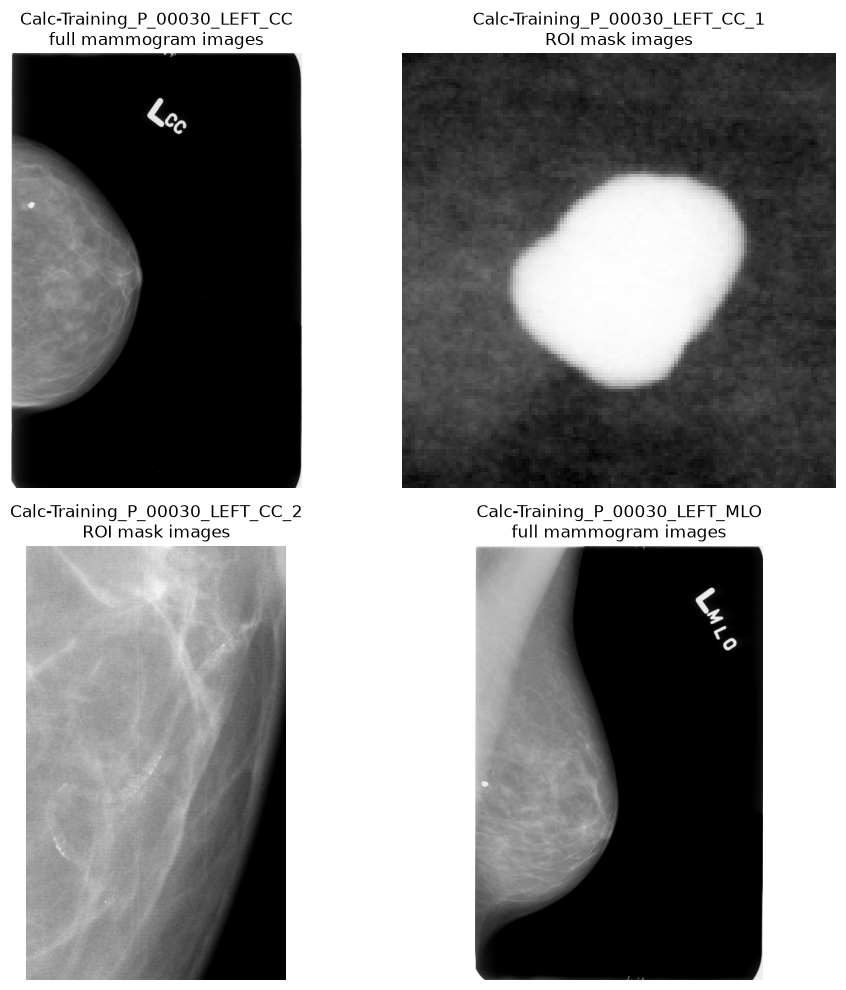

In [15]:
series_a_mostrar = series_locales.dropna(subset=["local_path"])
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for axis, (_, serie) in zip(axes.flat, series_a_mostrar.head(4).iterrows()):
    imagen = pydicom.dcmread(serie["local_path"]).pixel_array
    axis.imshow(imagen, cmap="gray")
    axis.set_title(f'{serie["Subject ID"]}\n{serie["Series Description"]}')
    axis.axis("off")

for axis in axes.flat[len(series_a_mostrar.head(4)) :]:
    axis.axis("off")

plt.tight_layout()
plt.show()

### Visualizar el caso copiado

Usaremos una imagen por serie para no saturar la memoria. Las imágenes completas muestran el contexto anatómico; las máscaras ROI muestran dónde está la anotación.

## 5. Comparar con un caso de masas

Ahora repetimos el recorrido con `Mass-Training_P_00001`. Usamos su CSV porque las masas tienen atributos distintos a las calcificaciones, como `mass shape` y `mass margins`.

In [16]:
MASS_CSV = DATA_DIR / "mass_case_description_train_set.csv"
mass_df = pd.read_csv(MASS_CSV)
mass_patient_id = "P_00001"

columnas_mass = [
    "patient_id",
    "left or right breast",
    "image view",
    "abnormality id",
    "mass shape",
    "mass margins",
    "assessment",
    "pathology",
    "subtlety",
]
mass_case = mass_df.loc[mass_df["patient_id"] == mass_patient_id, columnas_mass]
mass_case

,patient_id,left or right breast,image view,abnormality id,mass shape,mass margins,assessment,pathology,subtlety
0,P_00001,LEFT,CC,1,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4
1,P_00001,LEFT,MLO,1,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4


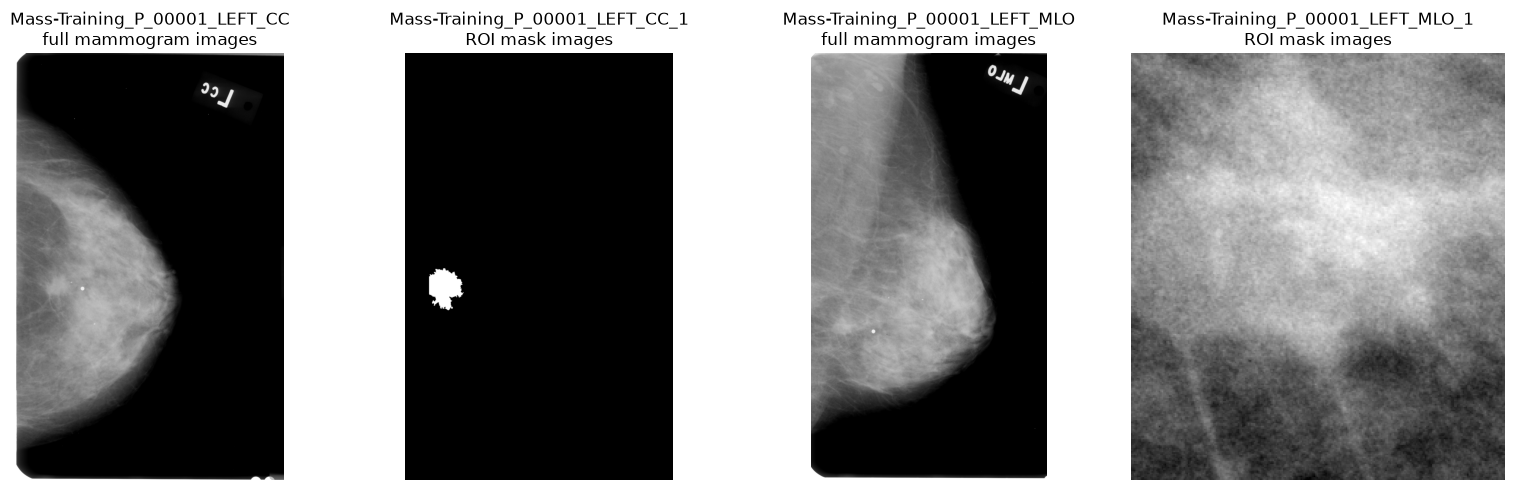

,Subject ID,Series Description,local_path
4134,Mass-Training_P_00001_LEFT_CC,full mammogram images,..\data\CBIS-DDSM\Mass-Training_P_00001_LEFT_C...
4135,Mass-Training_P_00001_LEFT_CC_1,ROI mask images,..\data\CBIS-DDSM\Mass-Training_P_00001_LEFT_C...
4136,Mass-Training_P_00001_LEFT_MLO,full mammogram images,..\data\CBIS-DDSM\Mass-Training_P_00001_LEFT_M...
4137,Mass-Training_P_00001_LEFT_MLO_1,ROI mask images,..\data\CBIS-DDSM\Mass-Training_P_00001_LEFT_M...


In [17]:
metadata_mass = metadata[
    metadata["Subject ID"].str.contains(f"Mass-Training_{mass_patient_id}", regex=False)
].copy()
series_mass = metadata_mass.assign(
    local_path=metadata_mass["File Location"].map(resolver_metadata)
)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for axis, (_, serie) in zip(axes, series_mass.dropna(subset=["local_path"]).iterrows()):
    imagen = pydicom.dcmread(serie["local_path"]).pixel_array
    axis.imshow(imagen, cmap="gray")
    axis.set_title(f'{serie["Subject ID"]}\n{serie["Series Description"]}')
    axis.axis("off")

plt.tight_layout()
plt.show()

series_mass[["Subject ID", "Series Description", "local_path"]]

In [ ]:
## Conclusión

Ahora el notebook contiene un ejemplo de cada tipo:

- `Calc`: P_00030, con tipos y distribución de calcificaciones.
- `Mass`: P_00001, con forma y márgenes de una masa.

Ambos casos comparten la lógica de vistas, anotaciones, diagnóstico y archivos DICOM, pero conservan sus variables específicas.